# Классификация: IC50 > медианы

## Цель работы
Построить и сравнить несколько моделей классификации для предсказания того, превышает ли значение IC50, mM медиану выборки.

## План
1. Загрузить данные.
2. Построить бинарную целевую переменную.
3. Подготовить признаки.
4. Разделить выборку на train/test.
5. Обучить несколько моделей классификации.
6. Сравнить модели по метрикам.
7. Подобрать гиперпараметры для лучшей модели.
8. Сделать вывод.

## За основу берем материал из лекций следующих модулей:
- **Модуль 3. Задачи классификации** - постановка бинарной классификации, логистическая регрессия, метрики классификации.
- **Модуль 4. Задачи классификации (ансамблевые модели)** - KNN, деревья решений, случайный лес.
- **Модуль 5. Метод опорных векторов** - SVC.
- **Модуль 6. Оптимизация и настройка моделей** - Pipeline, GridSearchCV, настройка гиперпараметров.

# 1. Импорт библиотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

# 2. Загрузка данных

In [ ]:
df = pd.read_excel("Данные_для_курсовои_Классическое_МО.xlsx")

print("Размер таблицы:", df.shape)
display(df.head())

Размер таблицы: (1001, 214)


,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,340.300,384.350449,158,0,0.038844,-0.293526,0.293526,0.038844,0.642857,1.035714,1.321429,14.822266,9.700470,2.600532,-2.343082,2.644698,-2.322229,5.944519,0.193481,3.150503,1.164038,611.920301,20.208896,19.534409,19.534409,13.127794,12.204226,12.204226,12.058078,12.058078,10.695991,10.695991,7.340247,7.340247,-0.66,2.187750e+06,20.606247,6.947534,2.868737,173.630124,0.000000,0.0,0.0,0.0,0.0,0.0,9.984809,0.0,0.0,0.0,54.384066,74.032366,35.342864,0.000000,0.000000,11.423370,0.0,0.000000,43.480583,105.750639,13.089513,0.00000,0,0.0,0.000000,0.000000,0.0,0.0,24.512883,0.000000,33.495774,105.750639,9.984809,0.0,0.0,0,24.72,0.0,0.0,0.0,0.000000,21.659962,24.925325,64.208216,11.42337,0.0,41.542423,9.984809,0.00000,0.0,10.188192,0.000000,4.807589,1.764908,0.000000,13.258223,16.981087,0.000000,0.923077,28,0,2,4,0,4,0,0,0,2,0,2,7,4,0,4,4,7.1212,121.5300,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,340.300,388.381750,162,0,0.012887,-0.313407,0.313407,0.012887,0.607143,1.000000,1.285714,14.975110,9.689226,2.614066,-2.394690,2.658342,-2.444817,5.134527,0.120322,3.150503,1.080362,516.780124,20.208896,19.794682,19.794682,13.127794,12.595754,12.595754,12.648545,12.

#3. Первичный анализ данных

In [ ]:
print("Список столбцов:")
display(df.columns.tolist())

print("Типы данных:")
display(df.dtypes.value_counts())

print("Пропуски по столбцам:")
display(df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False).head(20))

Список столбцов:


['Unnamed: 0',
 'IC50, mM',
 'CC50, mM',
 'SI',
 'MaxAbsEStateIndex',
 'MaxEStateIndex',
 'MinAbsEStateIndex',
 'MinEStateIndex',
 'qed',
 'SPS',
 'MolWt',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'NumValenceElectrons',
 'NumRadicalElectrons',
 'MaxPartialCharge',
 'MinPartialCharge',
 'MaxAbsPartialCharge',
 'MinAbsPartialCharge',
 'FpDensityMorgan1',
 'FpDensityMorgan2',
 'FpDensityMorgan3',
 'BCUT2D_MWHI',
 'BCUT2D_MWLOW',
 'BCUT2D_CHGHI',
 'BCUT2D_CHGLO',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'BCUT2D_MRHI',
 'BCUT2D_MRLOW',
 'AvgIpc',
 'BalabanJ',
 'BertzCT',
 'Chi0',
 'Chi0n',
 'Chi0v',
 'Chi1',
 'Chi1n',
 'Chi1v',
 'Chi2n',
 'Chi2v',
 'Chi3n',
 'Chi3v',
 'Chi4n',
 'Chi4v',
 'HallKierAlpha',
 'Ipc',
 'Kappa1',
 'Kappa2',
 'Kappa3',
 'LabuteASA',
 'PEOE_VSA1',
 'PEOE_VSA10',
 'PEOE_VSA11',
 'PEOE_VSA12',
 'PEOE_VSA13',
 'PEOE_VSA14',
 'PEOE_VSA2',
 'PEOE_VSA3',
 'PEOE_VSA4',
 'PEOE_VSA5',
 'PEOE_VSA6',
 'PEOE_VSA7',
 'PEOE_VSA8',
 'PEOE_VSA9',
 'SMR_VSA1',
 'SMR_VSA10',
 'SMR_VSA2',
 'SM

Типы данных:


,count
int64,107
float64,107


Пропуски по столбцам:


,0
MaxPartialCharge,3
MinPartialCharge,3
MaxAbsPartialCharge,3
MinAbsPartialCharge,3
BCUT2D_MWHI,3
BCUT2D_MWLOW,3
BCUT2D_CHGHI,3
BCUT2D_CHGLO,3
BCUT2D_LOGPHI,3
BCUT2D_LOGPLOW,3


## Первичный анализ данных

На этом этапе проводится базовый анализ структуры датасета:
- размер таблицы;
- названия столбцов;
- типы данных;
- наличие пропусков.

Подход основан на **модуле 2**, где подчёркивалась важность подготовки данных перед обучением модели.

#4. Построение целевой переменной

In [ ]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

median_ic50 = df["IC50, mM"].median()
print("Медиана IC50:", median_ic50)

df["target_ic50_median"] = (df["IC50, mM"] > median_ic50).astype(int)

print("Распределение классов:")
display(df["target_ic50_median"].value_counts())
display(df["target_ic50_median"].value_counts(normalize=True))

Медиана IC50: 46.58518345980803
Распределение классов:


,count
target_ic50_median,
0,501
1,500


,proportion
target_ic50_median,
0,0.5005
1,0.4995


#5. Визуализация распределения классов

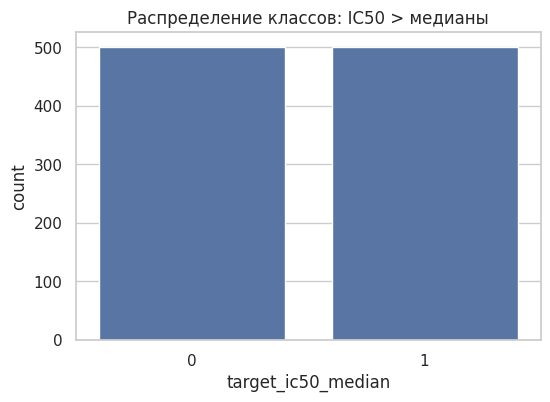

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x="target_ic50_median", data=df)
plt.title("Распределение классов: IC50 > медианы")
plt.show()

## Формирование целевой переменной

В этой задаче исходная непрерывная переменная IC50, mM преобразуется в бинарную:
- 0 - если значение не превышает медиану;
- 1 - если значение превышает медиану.

Такой подход соответствует постановке задачи бинарной классификации из **модуля 3**.

#6. Подготовка признаков

In [ ]:
X = df.drop(columns=[
    "IC50, mM",
    "CC50, mM",
    "SI",
    "target_ic50_median"
], errors="ignore")

y = df["target_ic50_median"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Размер X:", X.shape)
print("Размер y:", y.shape)
print("Числовых признаков:", len(numeric_features))
print("Категориальных признаков:", len(categorical_features))

Размер X: (1001, 210)
Размер y: (1001,)
Числовых признаков: 210
Категориальных признаков: 0


#7.Train/Test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 210)
X_test: (201, 210)
y_train: (800,)
y_test: (201,)


# 8. Предобработка

In [ ]:
preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


Так как в датасете почти все признаки числовые, используем:
- заполнение пропусков медианой;
- стандартизацию признаков.

Это основано на:
- **модуле 3** - подготовка данных для классификации;
- **модуле 5** - SVM чувствителен к масштабу признаков;
- **модуле 6** - организация предобработки через Pipeline.

#9. Список моделей

In [ ]:
models = {
    "LogisticRegression": LogisticRegression(random_state=42, max_iter=5000),
    "KNeighborsClassifier": KNeighborsClassifier(),
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
    "RandomForestClassifier": RandomForestClassifier(random_state=42),
    "SVC": SVC(probability=True, random_state=42)
}

## Почему были выбраны именно эти модели:

В задаче классификации были выбраны модели разной сложности:
- LogisticRegression как базовый линейный классификатор;
- KNN как метод, основанный на расстояниях;
- DecisionTree и RandomForest как деревообразные модели;
- SVC как метод опорных векторов.

Такой выбор позволяет исследовать, какой тип алгоритма лучше подходит для данного набора молекулярных дескрипторов.

#10. Обучение и сравнение моделей

In [ ]:
results = []

for model_name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    if hasattr(pipe, "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    if y_proba is not None:
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc
    })

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
display(results_df)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,RandomForestClassifier,0.691542,0.661017,0.78,0.715596,0.765990
4,SVC,0.691542,0.663793,0.77,0.712963,0.759059
0,LogisticRegression,0.681592,0.657895,0.75,0.700935,0.748465
1,KNeighborsClassifier,0.691542,0.682692,0.71,0.696078,0.754257
2,DecisionTreeClassifier,0.611940,0.605769,0.63,0.617647,0.623861


#11. Визуализация сравнения моделей

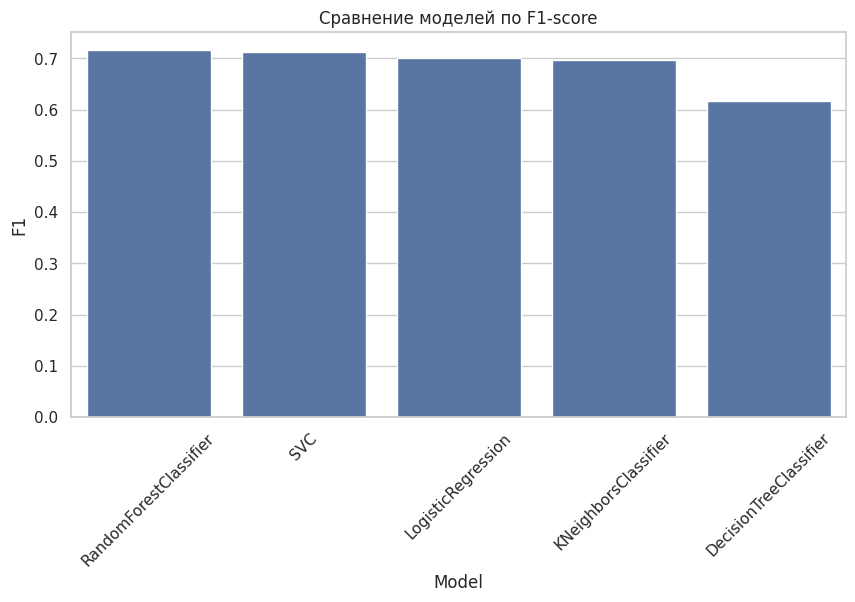

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="F1")
plt.xticks(rotation=45)
plt.title("Сравнение моделей по F1-score")
plt.show()

## Сравнение моделей

В работе сравниваются несколько моделей классификации:
- LogisticRegression - основана на **модуле 3**;
- KNeighborsClassifier, DecisionTreeClassifier, RandomForestClassifier - основаны на **модуле 4**;
- SVC - основан на **модуле 5**.

Для оценки используются метрики:
- Accuracy
- Precision
- Recall
- F1
- ROC-AUC

Выбор метрик основан на **модуле 3** и **модуле 4**, где подчеркивается, что одной accuracy недостаточно для полноценной оценки классификатора.

#12. Выбор лучшей модели

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
print("Лучшая модель по F1:", best_model_name)

Лучшая модель по F1: RandomForestClassifier


#13. Подбор гиперпараметров

In [ ]:
if best_model_name == "LogisticRegression":
    param_grid = {
        "model__C": [0.1, 1, 10]
    }
    best_model = LogisticRegression(random_state=42, max_iter=5000)

elif best_model_name == "KNeighborsClassifier":
    param_grid = {
        "model__n_neighbors": [3, 5, 7],
        "model__weights": ["uniform", "distance"]
    }
    best_model = KNeighborsClassifier()

elif best_model_name == "DecisionTreeClassifier":
    param_grid = {
        "model__max_depth": [3, 5, 10],
        "model__min_samples_split": [2, 5, 10]
    }
    best_model = DecisionTreeClassifier(random_state=42)

elif best_model_name == "RandomForestClassifier":
    param_grid = {
        "model__n_estimators": [100],
        "model__max_depth": [5, 10],
        "model__min_samples_split": [2, 5]
    }
    best_model = RandomForestClassifier(random_state=42, n_jobs=-1)

elif best_model_name == "SVC":
    param_grid = {
        "model__kernel": ["linear", "rbf"],
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", "auto"]
    }
    best_model = SVC(probability=True, random_state=42)

else:
    param_grid = {}
    best_model = LogisticRegression(random_state=42, max_iter=5000)

best_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

if param_grid:
    grid_search = GridSearchCV(
        estimator=best_pipe,
        param_grid=param_grid,
        cv=3,
        scoring="f1",
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    print("Лучшие параметры:")
    print(grid_search.best_params_)

    tuned_model = grid_search.best_estimator_
else:
    best_pipe.fit(X_train, y_train)
    tuned_model = best_pipe

Лучшие параметры:
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 100}


#14. Оценка лучшей модели после настройки

In [ ]:
y_pred_tuned = tuned_model.predict(X_test)
y_proba_tuned = tuned_model.predict_proba(X_test)[:, 1]

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned, zero_division=0)
recall_tuned = recall_score(y_test, y_pred_tuned, zero_division=0)
f1_tuned = f1_score(y_test, y_pred_tuned, zero_division=0)
roc_auc_tuned = roc_auc_score(y_test, y_proba_tuned)

print("Метрики лучшей модели после настройки:")
print("Accuracy:", accuracy_tuned)
print("Precision:", precision_tuned)
print("Recall:", recall_tuned)
print("F1:", f1_tuned)
print("ROC-AUC:", roc_auc_tuned)

Метрики лучшей модели после настройки:
Accuracy: 0.7164179104477612
Precision: 0.680672268907563
Recall: 0.81
F1: 0.7397260273972602
ROC-AUC: 0.7832178217821781


#15. Матрица ошибок

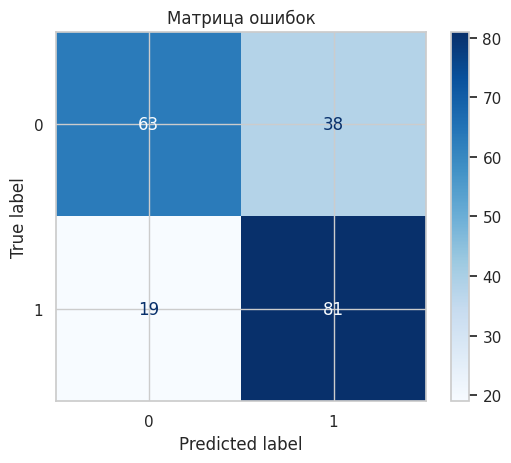

Classification report:
              precision    recall  f1-score   support

           0       0.77      0.62      0.69       101
           1       0.68      0.81      0.74       100

    accuracy                           0.72       201
   macro avg       0.72      0.72      0.71       201
weighted avg       0.72      0.72      0.71       201



In [ ]:
cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Матрица ошибок")
plt.show()

print("Classification report:")
print(classification_report(y_test, y_pred_tuned, zero_division=0))

## Подбор гиперпараметров

Подбор гиперпараметров выполнен с помощью GridSearchCV.

Этот блок основан на:
- **модуле 6** - GridSearchCV, настройка гиперпараметров;
- **модуле 4** - сравнение ансамблевых и других классификационных моделей;
- **модуле 5** - если лучшей моделью оказывается SVC, используются параметры C, kernel, gamma.

# 16. Анализ важности признаков

Для лучшей модели дополнительно проводится анализ вклада признаков.  
Это позволяет понять, какие молекулярные дескрипторы сильнее влияют на решение классификатора.

Данный блок опирается на:
- **модуль 4** - деревья решений и случайный лес;
- **модуль 6** - интерпретируемость модели и отбор признаков.

,Feature,Importance
103,VSA_EState8,0.029360
25,BCUT2D_MRLOW,0.025864
19,BCUT2D_MWLOW,0.020498
11,MaxPartialCharge,0.015188
78,SlogP_VSA5,0.015148
57,PEOE_VSA6,0.014370
93,EState_VSA8,0.014085
123,MolLogP,0.013594
60,PEOE_VSA9,0.013506
102,VSA_EState7,0.012949


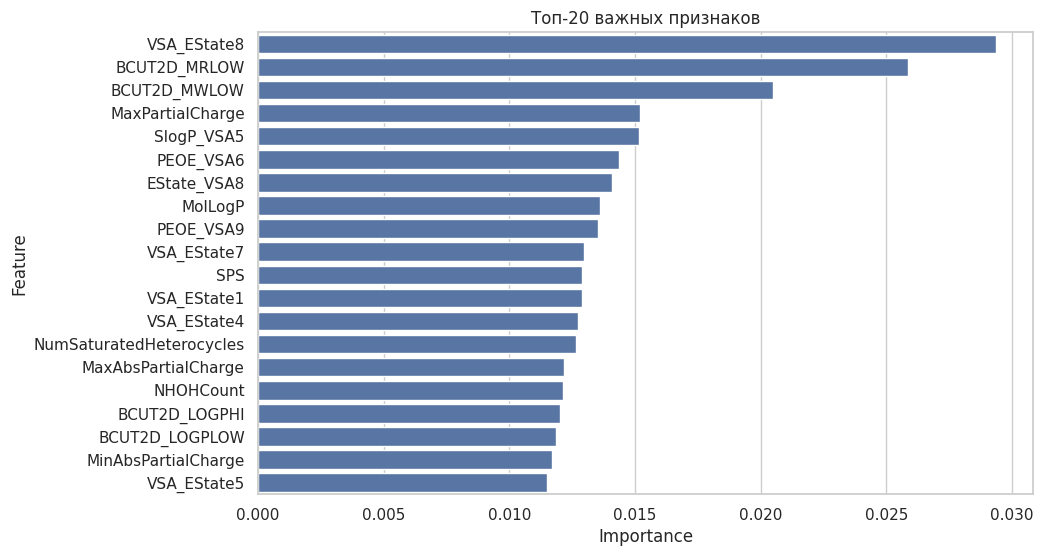

In [ ]:
if best_model_name in ["DecisionTreeClassifier", "RandomForestClassifier"]:
    model_step = tuned_model.named_steps["model"]

    feature_importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": model_step.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    display(feature_importance_df.head(20))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance_df.head(20), x="Importance", y="Feature")
    plt.title("Топ-20 важных признаков")
    plt.show()

elif best_model_name == "LogisticRegression":
    model_step = tuned_model.named_steps["model"]

    coef_df = pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": model_step.coef_[0]
    })

    coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()
    coef_df = coef_df.sort_values(by="AbsCoefficient", ascending=False)

    display(coef_df.head(20))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=coef_df.head(20), x="AbsCoefficient", y="Feature")
    plt.title("Топ-20 признаков по модулю коэффициента")
    plt.show()

# Итоговый вывод

В данной задаче была построена и проанализирована модель классификации для предсказания того, превышает ли IC50, mM медиану выборки.

На этапе первичного сравнения лучшей моделью по метрике F1 оказался RandomForestClassifier.

После настройки гиперпараметров с помощью GridSearchCV были получены следующие параметры:
- max_depth = 10
- min_samples_split = 5
- n_estimators = 100

Итоговые метрики лучшей модели на тестовой выборке:
- Accuracy = 0.7164
- Precision = 0.6807
- Recall = 0.8100
- F1 = 0.7397
- ROC-AUC = 0.7832

Сравнение результатов до и после настройки гиперпараметров показало, что подбор параметров улучшил качество модели.  
Особенно важно, что выросли F1-score и ROC-AUC, а также увеличилась полнота (Recall), то есть модель стала лучше выявлять объекты класса 1.


# Рекомендации по улучшению модели

Для дальнейшего улучшения качества классификации можно рассмотреть следующие шаги:

1. **Провести более детальный отбор признаков**  
   Это может помочь убрать шумовые дескрипторы и сделать модель более устойчивой.

2. **Проверить баланс классов и влияние порога**  
   Так как целевая переменная построена по медиане, классы обычно близки к балансу, но полезно дополнительно проверить, как изменится качество при варьировании порога классификации.

3. **Сравнить качество после настройки нескольких моделей, а не одной**  
   В текущей версии гиперпараметры подбираются только для лучшей модели, но можно дополнительно настроить 2-3 сильных алгоритма и сравнить их заново.

4. **Проверить устойчивость результата на кросс-валидации**  
   Это позволит оценить, насколько модель устойчива к разным разбиениям данных.